---
**Title:** DPO — 直接偏好优化

**Chapter:** 强化学习与大语言模型

**Difficulty:** 中级

**Estimated Time:** 45 分钟

---

## 1 — 概览

在前两个 Notebook 中，我们用 **REINFORCE**（nb 00）和 **PPO**（nb 01）训练了一个微型语言模型。PPO 效果不错，但流程复杂：

- **4 个模型**同时在内存中（Actor、Critic、奖励模型、参考模型）
- 需要单独的奖励模型训练阶段
- 大量超参数需要调优（裁剪范围、KL 系数、价值函数系数……）

2023 年，Rafailov 等人展示了一条令人惊讶的捷径：**我们可以直接针对人类偏好进行优化，完全不需要训练奖励模型。** 这个方法就是 **直接偏好优化（Direct Preference Optimization，DPO）**。

| PPO 流程 | DPO 流程 |
|---|---|
| 训练奖励模型 → 训练价值函数 → 运行 PPO 循环 | 收集偏好对（Preference Pairs）→ 运行 DPO（完成）|
| 4 个模型在内存中 | **2 个模型**（策略 + 参考）|

本 Notebook 的剩余部分将从零开始、一步一步地构建 DPO。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from collections import Counter

from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import draw_rl_algorithm_comparison, draw_training_pipeline
from mp_tutorial.formatting import info_box, comparison_table, formula_breakdown

import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Ready!")

Ready!


In [2]:
# -- Our tiny language model (same as notebooks 00 and 01) --
VOCAB = ["I", "love", "cats", "hate", "dogs"]
V = len(VOCAB)
SEQ_LEN = 3

def decode(token_ids):
    """Convert token indices to words."""
    return " ".join(VOCAB[t] for t in token_ids.tolist())


class TinyLM(nn.Module):
    """A minimal autoregressive language model.

    Given a sequence of tokens, predicts the next token at each position.
    This is exactly what GPT does -- just with 5 words instead of 50,000.
    """
    def __init__(self, vocab_size=V, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """Forward pass (teacher-forced): returns logits at every position."""
        e = self.embed(x)
        h, _ = self.rnn(e)
        return self.head(h)  # (batch, seq_len, vocab_size)

    def log_probs_of(self, sequences):
        """Compute log P(sequence) under the current policy.

        Sums log-probabilities of tokens at positions 1, 2, ..., T-1
        (position 0 is the fixed start token).
        """
        logits = self.forward(sequences)           # (B, T, V)
        dist = torch.distributions.Categorical(logits=logits[:, :-1, :])
        per_token = dist.log_prob(sequences[:, 1:])  # (B, T-1)
        return per_token.sum(dim=1)                   # (B,)

    @torch.no_grad()
    def generate(self, batch_size, seq_len=SEQ_LEN):
        """Generate sequences autoregressively (always starts with 'I')."""
        tokens = [torch.zeros(batch_size, 1, dtype=torch.long)]
        for _ in range(seq_len - 1):
            inp = torch.cat(tokens, dim=1)
            logits = self.forward(inp)[:, -1, :]
            token = torch.distributions.Categorical(logits=logits).sample()
            tokens.append(token.unsqueeze(1))
        return torch.cat(tokens, dim=1)


def reward_fn(sequences):
    """Score sequences: +1 for 'I love cats', penalize 'hate'.

    This is our stand-in for human preferences.
    In real RLHF, a learned reward model replaces this function.
    """
    rewards = []
    for seq in sequences:
        words = [VOCAB[t] for t in seq.tolist()]
        r = 0.0
        if "love" in words and "cats" in words:
            r = 1.0
        elif "love" in words:
            r = 0.3
        if "hate" in words:
            r -= 0.5
        rewards.append(r)
    return torch.tensor(rewards)


# Quick test
model = TinyLM()
seqs = model.generate(8)
for seq in seqs:
    print(f"  {decode(seq):20s}  reward = {reward_fn(seq.unsqueeze(0)).item():+.1f}")

  I I I                 reward = +0.0
  I cats love           reward = +1.0
  I cats dogs           reward = +0.0
  I cats hate           reward = -0.5
  I love I              reward = +0.3
  I hate dogs           reward = -0.5
  I hate love           reward = -0.2
  I dogs I              reward = +0.0


## 2 — 复杂性问题

回顾上一个 Notebook 中的 PPO 流程：

1. 在人类偏好数据上**训练一个奖励模型**
2. **训练一个价值函数**（评论模型，Critic）来估计预期未来奖励
3. **运行 PPO 循环**：生成 → 打分 → 计算优势（Advantage）→ 更新策略（带裁剪）

这需要**同时在 GPU 内存中放 4 个模型**：

| 模型 | 角色 | 是否可训练？ |
|---|---|---|
| Actor（策略） | 生成文本 | 是 |
| Critic（价值函数） | 估计优势 | 是 |
| 奖励模型 | 给回答打分 | 冻结 |
| 参考模型 | KL 锚点 | 冻结 |

对于一个 7B 参数的模型，fp16 下大约 4 × 14 GB = **56 GB** 仅用于权重 — 还没算优化器状态、激活值和梯度。

> **如果我们能从偏好数据直接到更好的策略，跳过奖励模型呢？**

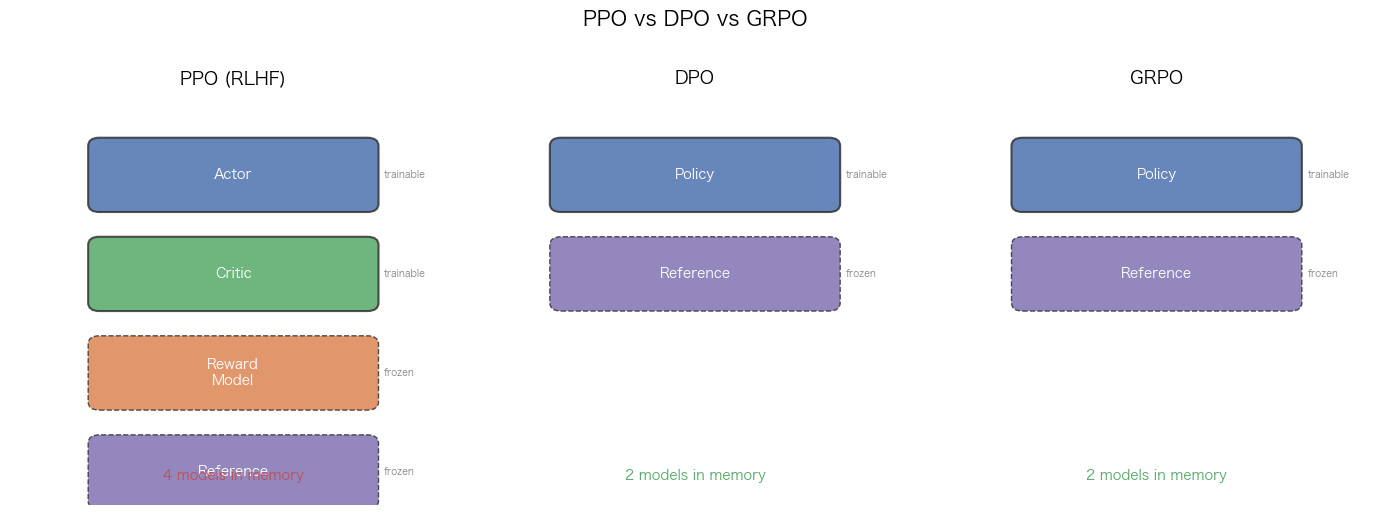

In [3]:
fig, axes = draw_rl_algorithm_comparison()
plt.show()

info_box("DPO replaces PPO's 4-model pipeline with just 2 models. "
         "No reward model, no value function, no multi-phase training loop. "
         "The key: a mathematical shortcut that connects preferences directly to the policy.",
         title="The Simplification")

## 3 — 什么是偏好对（Preference Pairs）？

在 RLHF 中，我们收集**人类偏好**：给定一个提示词，人类标注员查看两个候选回答，然后说*“A 比 B 好”*。

这为每个提示词 $x$ 创建了**偏好对**：

$$\bigl(\, y_w ,\; y_l \,\bigr) \quad \text{where } y_w \succ y_l$$

- $y_w$ — **偏好的**（获胜的）回答
- $y_l$ — **被拒绝的**（失败的）回答

**示例：**

| 提示词 | 偏好的（$y_w$） | 被拒绝的（$y_l$） |
|---|---|---|
| *“给我讲讲猫”* | *“猫是迷人的生物……”* | *“不知道，猫就那样吧”* |

对于我们的玩具模型，我们将使用 `reward_fn` 来构造偏好对：包含 "love" 的序列优于包含 "hate" 的序列。

Preference pairs (preferred > rejected):

  ✓ I love cats          (r=+1.0)   >   ✗ I hate cats          (r=-0.5)
  ✓ I love dogs          (r=+0.3)   >   ✗ I hate dogs          (r=-0.5)
  ✓ I love dogs          (r=+0.3)   >   ✗ hate dogs I          (r=-0.5)
  ✓ I love cats          (r=+1.0)   >   ✗ hate dogs I          (r=-0.5)
  ✓ I love cats          (r=+1.0)   >   ✗ hate dogs I          (r=-0.5)


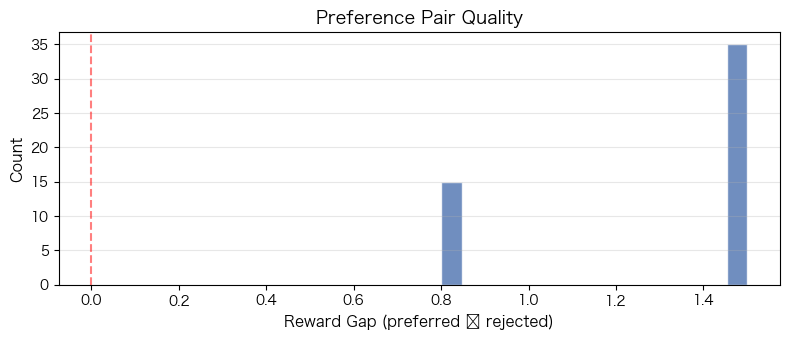

In [4]:
# Create preference pairs from our reward function
torch.manual_seed(42)
n_pairs = 500
preferred, rejected = [], []
for _ in range(n_pairs):
    good = [[0, 1, 2], [0, 1, 4], [2, 1, 0]][np.random.randint(3)]  # love-containing
    bad  = [[0, 3, 2], [0, 3, 4], [3, 4, 0]][np.random.randint(3)]  # hate-containing
    preferred.append(good)
    rejected.append(bad)
preferred_t = torch.tensor(preferred)
rejected_t = torch.tensor(rejected)

# Show some examples
print("Preference pairs (preferred > rejected):\n")
for i in range(5):
    pw = decode(preferred_t[i])
    pl = decode(rejected_t[i])
    rw = reward_fn(preferred_t[i:i+1]).item()
    rl = reward_fn(rejected_t[i:i+1]).item()
    print(f"  \u2713 {pw:20s} (r={rw:+.1f})   >   \u2717 {pl:20s} (r={rl:+.1f})")

# Visualize the preference gap
fig, ax = plt.subplots(figsize=(8, 3.5))
pref_rewards = reward_fn(preferred_t[:50]).numpy()
rej_rewards = reward_fn(rejected_t[:50]).numpy()
gaps = pref_rewards - rej_rewards

ax.hist(gaps, bins=15, color='#4C72B0', edgecolor='white', alpha=0.8)
ax.set_xlabel("Reward Gap (preferred \u2212 rejected)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Preference Pair Quality", fontsize=13, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', lw=1.5, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

info_box("Every pair has a clear gap: the preferred output always has a higher reward. "
         "In real RLHF, these comparisons come from human annotators. "
         "DPO learns directly from these pairs \u2014 no need to train a reward model first.",
         title="Preference Pairs")

## 4 — Bradley-Terry 偏好模型

我们如何用数学来建模人类偏好？

**Bradley-Terry 模型**说，人类偏好回答 $A$ 而非回答 $B$ 的概率为：

$$P(A \succ B) \;=\; \sigma\bigl(r(A) - r(B)\bigr)$$

其中 $\sigma$ 是 **sigmoid 函数** $\sigma(x) = \frac{1}{1 + e^{-x}}$。

直觉上：

| 情况 | $r(A) - r(B)$ | $P(A \succ B)$ |
|---|---|---|
| A 远好于 B | $\gg 0$ | $\approx 1$ |
| A 和 B 差不多 | $= 0$ | $= 0.5$（掷硬币）|
| B 远好于 A | $\ll 0$ | $\approx 0$ |

In [5]:
info_box("This is the same model used in <b>chess Elo ratings</b>! "
         "If your rating is much higher than your opponent's, you are very likely to win. "
         "If the ratings are close, the outcome is nearly a coin flip.",
         title="Bradley-Terry: Where You Have Seen It Before")

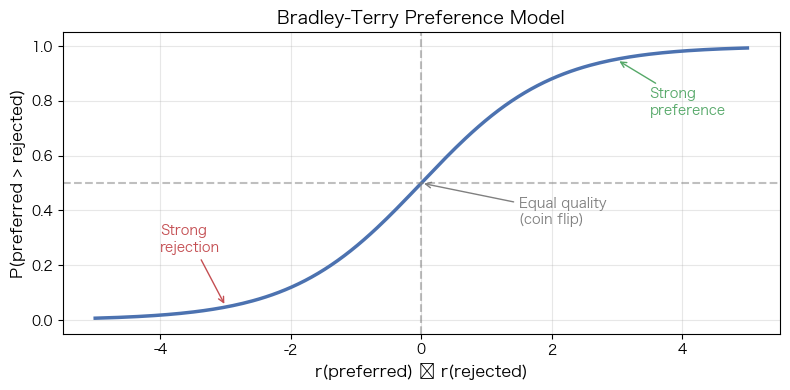

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-5, 5, 200)
y = 1 / (1 + np.exp(-x))
ax.plot(x, y, color='#4C72B0', lw=2.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("r(preferred) \u2212 r(rejected)", fontsize=12)
ax.set_ylabel("P(preferred > rejected)", fontsize=12)
ax.set_title("Bradley-Terry Preference Model", fontsize=13, fontweight='bold')

# Annotate key points
ax.annotate('Equal quality\n(coin flip)', xy=(0, 0.5), xytext=(1.5, 0.35),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'), color='gray')
ax.annotate('Strong\npreference', xy=(3, 0.95), xytext=(3.5, 0.75),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='#55A868'), color='#55A868')
ax.annotate('Strong\nrejection', xy=(-3, 0.05), xytext=(-4, 0.25),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='#C44E52'), color='#C44E52')

ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 5 — 数学捷径

这是使 DPO 成立的关键推导。我们将一步一步来。

### 第一步 — 最优策略的闭式解

标准 RLHF 目标是：在保持与参考策略 $\pi_{\text{ref}}$ 接近（KL 散度意义下）的同时最大化奖励。事实证明，这个目标有一个**闭式解**：

$$\pi^*(a \mid s) \;=\; \frac{1}{Z(s)}\; \pi_{\text{ref}}(a \mid s) \;\cdot\; \exp\!\left(\frac{1}{\beta}\, r(a, s)\right)$$

其中 $Z(s)$ 是归一化常数（配分函数），$\beta$ 控制策略可以偏离参考多远。

### 第二步 — 用策略表示奖励

重新排列以求解 $r$：

$$r(a, s) \;=\; \beta \log \frac{\pi^*(a \mid s)}{\pi_{\text{ref}}(a \mid s)} \;+\; \beta \log Z(s)$$

奖励现在完全用**策略对数比**加上一个常数来表示。

### 第三步 — 代入 Bradley-Terry

将奖励表达式代入 Bradley-Terry 偏好模型。$Z(s)$ 项**被消去**，因为偏好的和被拒绝的回答共享同一个提示词：

$$\boxed{L_{\text{DPO}} = -\log \sigma\!\left(\, \beta \left[\, \log \frac{\pi_\theta(y_w)}{\pi_{\text{ref}}(y_w)} \;-\; \log \frac{\pi_\theta(y_l)}{\pi_{\text{ref}}(y_l)} \,\right] \right)}$$

**通俗来说：** 让模型更可能生成偏好的输出，更不可能生成被拒绝的输出，*相对于参考模型而言*。

In [7]:
formula_breakdown([
    (
        "Log-ratio for preferred output \u2014<br>"
        "how much more likely is y<sub>w</sub> under our<br>"
        "policy than under the reference?",
        "log \u03c0<sub>\u03b8</sub>(y<sub>w</sub>) \u2212 log \u03c0<sub>ref</sub>(y<sub>w</sub>)",
        "lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)",
    ),
    (
        "Log-ratio for rejected output \u2014<br>"
        "same comparison for the bad response",
        "log \u03c0<sub>\u03b8</sub>(y<sub>l</sub>) \u2212 log \u03c0<sub>ref</sub>(y<sub>l</sub>)",
        "lp_l = policy.log_probs_of(rejected) - ref.log_probs_of(rejected)",
    ),
    (
        "DPO loss \u2014 push the gap between<br>"
        "preferred and rejected log-ratios apart",
        "\u2212log \u03c3(\u03b2 \u00b7 (lp_w \u2212 lp_l))",
        "loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()",
    ),
], title="DPO Loss \u2014 Term by Term")

In Plain English,Math,PyTorch
Log-ratio for preferred output —how much more likely is yw under ourpolicy than under the reference?,log πθ(yw) − log πref(yw),lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)
Log-ratio for rejected output —same comparison for the bad response,log πθ(yl) − log πref(yl),lp_l = policy.log_probs_of(rejected) - ref.log_probs_of(rejected)
DPO loss — push the gap betweenpreferred and rejected log-ratios apart,−log σ(β · (lp_w − lp_l)),loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()


## 6 — 实现

注意 DPO 有多简单。**整个损失函数**只需要三行 PyTorch：

```python
lp_w = policy.log_probs_of(preferred) - ref.log_probs_of(preferred)
lp_l = policy.log_probs_of(rejected)  - ref.log_probs_of(rejected)
loss  = -F.logsigmoid(beta * (lp_w - lp_l)).mean()
```

对比 PPO 需要裁剪机制、价值函数头、KL 惩罚计算和每批多次更新轮次。DPO 将所有这些压缩成一个简洁的目标函数。

In [8]:
# ── Train with DPO ──
torch.manual_seed(42)
policy = TinyLM()
ref_model = deepcopy(policy)
for p in ref_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)
beta = 0.1
dpo_losses = []

for step in range(300):
    idx = torch.randint(n_pairs, (64,))
    pref_batch = preferred_t[idx]
    rej_batch = rejected_t[idx]

    # DPO loss (just 3 lines!)
    lp_w = policy.log_probs_of(pref_batch) - ref_model.log_probs_of(pref_batch)
    lp_l = policy.log_probs_of(rej_batch) - ref_model.log_probs_of(rej_batch)
    loss = -F.logsigmoid(beta * (lp_w - lp_l)).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    dpo_losses.append(loss.item())
    if step % 60 == 0:
        print(f"Step {step:3d}  loss = {loss.item():.4f}")

# Check what the DPO-trained model generates
print("\nAfter DPO training:")
seqs = policy.generate(200)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(8):
    r = reward_fn(torch.tensor([[VOCAB.index(w) for w in text.split()]])).item()
    print(f"  {text:20s}  freq={count/200:.0%}  reward={r:+.1f}")

Step   0  loss = 0.6931
Step  60  loss = 0.1262
Step 120  loss = 0.0383


Step 180  loss = 0.0208
Step 240  loss = 0.0137

After DPO training:
  I love dogs           freq=50%  reward=+0.3
  I love cats           freq=41%  reward=+1.0
  I love I              freq=5%  reward=+0.3
  I love hate           freq=4%  reward=-0.2


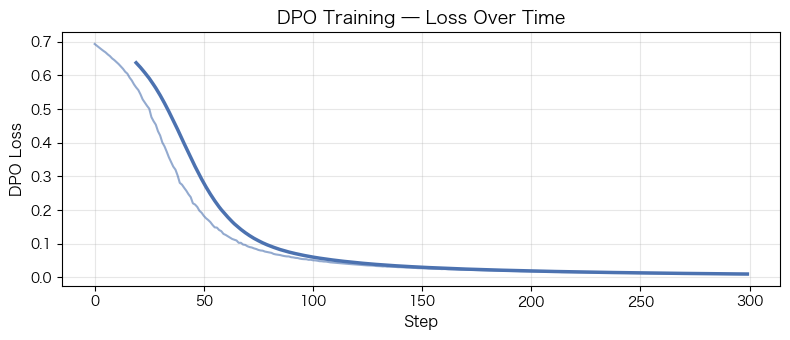

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(dpo_losses, color='#4C72B0', lw=1.5, alpha=0.6)
window = 20
smoothed = np.convolve(dpo_losses, np.ones(window)/window, mode='valid')
ax.plot(range(window-1, len(dpo_losses)), smoothed, color='#4C72B0', lw=2.5)
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel("DPO Loss", fontsize=11)
ax.set_title("DPO Training \u2014 Loss Over Time", fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

info_box("The loss drops smoothly from 0.693 (random, = log 2) to near 0. "
         "This means the model has learned to strongly prefer the good sequences "
         "over the bad ones. No reward model needed!", title="DPO Training")

## 7 — DPO 如何更新策略

DPO 实际上对模型权重做了什么？

对于每个偏好对 $(y_w, y_l)$：

1. DPO **增加** $\log \pi_\theta(y_w)$ — 使偏好的输出更有可能。
2. DPO **减少** $\log \pi_\theta(y_l)$ — 使被拒绝的输出更不可能。

但它是**相对于参考模型**来做的，这一点很重要：

- 如果参考模型已经强烈偏好 $y_w$，那就没什么可学的 — DPO 几乎不改变权重。
- 如果参考模型在 $y_w$ 和 $y_l$ 之间**犹豫不决**，DPO 会大力推动 — 这才是模型能获益最多的地方。

参考模型充当锚点：DPO 只在当前模型困惑的地方“花力气”。

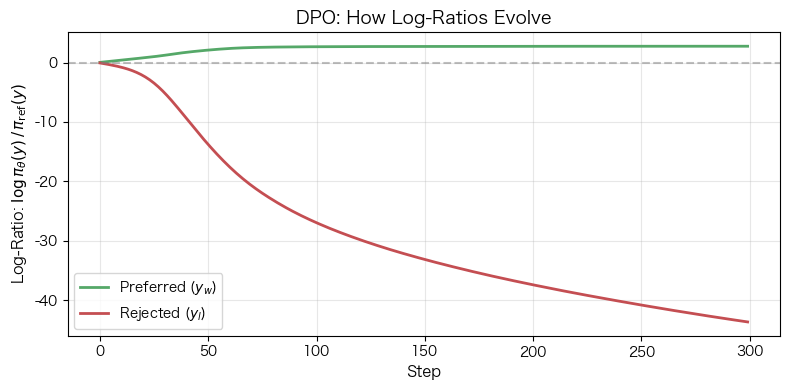

In [10]:
# Track how log-ratios change during training
torch.manual_seed(42)
policy_track = TinyLM()
ref_track = deepcopy(policy_track)
for p in ref_track.parameters():
    p.requires_grad = False
opt_track = torch.optim.Adam(policy_track.parameters(), lr=5e-3)

# Track log-ratios for a fixed batch
fixed_pref = preferred_t[:16]
fixed_rej = rejected_t[:16]

lr_preferred_hist, lr_rejected_hist = [], []
for step in range(300):
    idx = torch.randint(n_pairs, (64,))
    pref_batch = preferred_t[idx]
    rej_batch = rejected_t[idx]
    lp_w = policy_track.log_probs_of(pref_batch) - ref_track.log_probs_of(pref_batch)
    lp_l = policy_track.log_probs_of(rej_batch) - ref_track.log_probs_of(rej_batch)
    loss = -F.logsigmoid(0.1 * (lp_w - lp_l)).mean()
    opt_track.zero_grad()
    loss.backward()
    opt_track.step()

    with torch.no_grad():
        lr_w = (policy_track.log_probs_of(fixed_pref) - ref_track.log_probs_of(fixed_pref)).mean().item()
        lr_l = (policy_track.log_probs_of(fixed_rej) - ref_track.log_probs_of(fixed_rej)).mean().item()
    lr_preferred_hist.append(lr_w)
    lr_rejected_hist.append(lr_l)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lr_preferred_hist, color='#55A868', lw=2, label='Preferred ($y_w$)')
ax.plot(lr_rejected_hist, color='#C44E52', lw=2, label='Rejected ($y_l$)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Step", fontsize=11)
ax.set_ylabel(r"Log-Ratio: $\log \pi_\theta(y)\,/\,\pi_{\mathrm{ref}}(y)$", fontsize=11)
ax.set_title("DPO: How Log-Ratios Evolve", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

info_box("Preferred outputs become <b>more likely</b> under the policy (positive log-ratio). "
         "Rejected outputs become <b>less likely</b> (negative log-ratio). "
         "DPO pushes these apart \u2014 that is the optimisation objective.",
         title="Log-Ratio Dynamics")

## 8 — 在线（Online）与离线（Offline）RL

一个重要的区分：

- **DPO 是离线的**：它在一个**固定的**偏好对数据集上训练。模型在训练过程中从不生成新数据。
- **PPO 是在线的（On-policy）**：它在每一步从*当前*策略生成新数据并从中学习。

这是一个根本性的权衡：

| | 离线（DPO） | 在线（PPO） |
|---|---|---|
| **简单性** | 非常简单 | 复杂 |
| **稳定性** | 非常稳定 | 可能不稳定 |
| **探索能力** | 限于数据集 | 能发现新策略 |
| **计算开销** | 低（仅训练） | 高（生成 + 训练） |

离线更简单、更便宜，但模型只能从数据集中出现的策略中学习。在线方法能发现标注员从未演示过的新策略。

In [11]:
comparison_table(
    headers=["Property", "Online (PPO)", "Offline (DPO)"],
    rows=[
        ["Data", "Generated by current policy", "Fixed preference dataset"],
        ["Exploration", "Discovers new strategies", "Limited to dataset distribution"],
        ["Complexity", "4 models, multi-phase", "2 models, single-phase"],
        ["Stability", "Can be unstable", "Very stable"],
        ["Compute", "Expensive (generation + training)", "Cheap (training only)"],
    ],
    title="Online vs Offline RL"
)

Property,Online (PPO),Offline (DPO)
Data,Generated by current policy,Fixed preference dataset
Exploration,Discovers new strategies,Limited to dataset distribution
Complexity,"4 models, multi-phase","2 models, single-phase"
Stability,Can be unstable,Very stable
Compute,Expensive (generation + training),Cheap (training only)


## 9 — DPO 变体

DPO 的简洁性催生了一系列相关算法，每个都解决一个特定的局限：

### IPO — 恒等偏好优化（Identity Preference Optimisation）

用更简单的**平方损失**替代 log-sigmoid 损失来处理对数比的差距。这避免了 DPO 在同一偏好数据上训练过久时可能出现的过拟合问题。

### KTO — Kahneman-Tversky 优化

根本不需要偏好*对* — 只需要标记为“点赞”或“踩”的单个回答。这大大降低了收集成本：标注员每次只需判断一个回答，而非比较两个。

### cDPO — 保守 DPO（Conservative DPO）

显式处理偏好数据中的**标签噪声**。如果你的偏好对中有 10% 被意外搞反了（标注员犯了错），cDPO 能优雅地降级，而标准 DPO 则不行。

In [12]:
info_box("DPO spawned a family of algorithms. They all share the core insight: "
         "optimise preferences directly, no reward model. "
         "The differences are in the loss function and the data requirements.",
         title="The DPO Family")

## 10 — DPO 对比 PPO：正面对决

让我们在玩具问题上训练两种算法，并在训练过程中比较生成序列的质量。

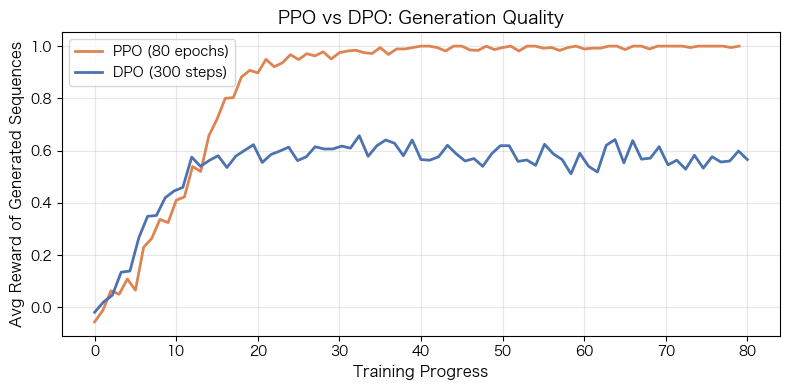

In [13]:
# ── Quick PPO training for comparison ──
torch.manual_seed(42)
ppo_policy = TinyLM()
ppo_ref = deepcopy(ppo_policy)
for p in ppo_ref.parameters():
    p.requires_grad = False
ppo_opt = torch.optim.Adam(ppo_policy.parameters(), lr=3e-3)
ppo_rewards = []

for epoch in range(80):
    seqs = ppo_policy.generate(128)
    rewards = reward_fn(seqs)
    with torch.no_grad():
        old_lp = ppo_policy.log_probs_of(seqs)
        ref_lp = ppo_ref.log_probs_of(seqs)
    advantages = rewards - rewards.mean()
    for _ in range(4):
        new_lp = ppo_policy.log_probs_of(seqs)
        ratio = (new_lp - old_lp).exp()
        s1 = ratio * advantages
        s2 = torch.clamp(ratio, 0.8, 1.2) * advantages
        ppo_loss = -torch.min(s1, s2).mean()
        kl = (new_lp - ref_lp).mean()
        loss = ppo_loss + 0.15 * kl
        ppo_opt.zero_grad()
        loss.backward()
        ppo_opt.step()
    ppo_rewards.append(rewards.mean().item())

# ── DPO training with periodic generation quality evaluation ──
torch.manual_seed(42)
dpo_pol = TinyLM()
dpo_ref2 = deepcopy(dpo_pol)
for p in dpo_ref2.parameters():
    p.requires_grad = False
dpo_opt2 = torch.optim.Adam(dpo_pol.parameters(), lr=5e-3)
dpo_gen_rewards = []

for step in range(300):
    idx = torch.randint(n_pairs, (64,))
    lp_w = dpo_pol.log_probs_of(preferred_t[idx]) - dpo_ref2.log_probs_of(preferred_t[idx])
    lp_l = dpo_pol.log_probs_of(rejected_t[idx]) - dpo_ref2.log_probs_of(rejected_t[idx])
    loss = -F.logsigmoid(0.1 * (lp_w - lp_l)).mean()
    dpo_opt2.zero_grad()
    loss.backward()
    dpo_opt2.step()
    if step % 4 == 0:  # Sample every 4th step to match PPO epochs
        with torch.no_grad():
            gen = dpo_pol.generate(128)
            dpo_gen_rewards.append(reward_fn(gen).mean().item())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ppo_rewards, color='#DD8452', lw=2, label='PPO (80 epochs)')
ax.plot(np.linspace(0, 80, len(dpo_gen_rewards)), dpo_gen_rewards,
        color='#4C72B0', lw=2, label='DPO (300 steps)')
ax.set_xlabel("Training Progress", fontsize=11)
ax.set_ylabel("Avg Reward of Generated Sequences", fontsize=11)
ax.set_title("PPO vs DPO: Generation Quality", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11 — $\beta$ 的作用

DPO 损失中的超参数 $\beta$ 控制策略允许偏离参考多远：

$$L_{\text{DPO}} = -\log \sigma\!\left(\, \beta \bigl[\, \text{log-ratio}_w - \text{log-ratio}_l \,\bigr] \right)$$

- **小 $\beta$**（如 0.05）：模型可以大幅偏离参考。学习更快但有**模式崩溃（Mode Collapse）** 风险 — 模型可能只生成一个序列。
- **大 $\beta$**（如 0.5）：模型保持接近参考。更安全但学习更慢。
- **实践中的典型值**：$\beta \in [0.1, 0.5]$。

这类似于 PPO 中的 KL 系数 — 两者都控制探索与利用之间的权衡。

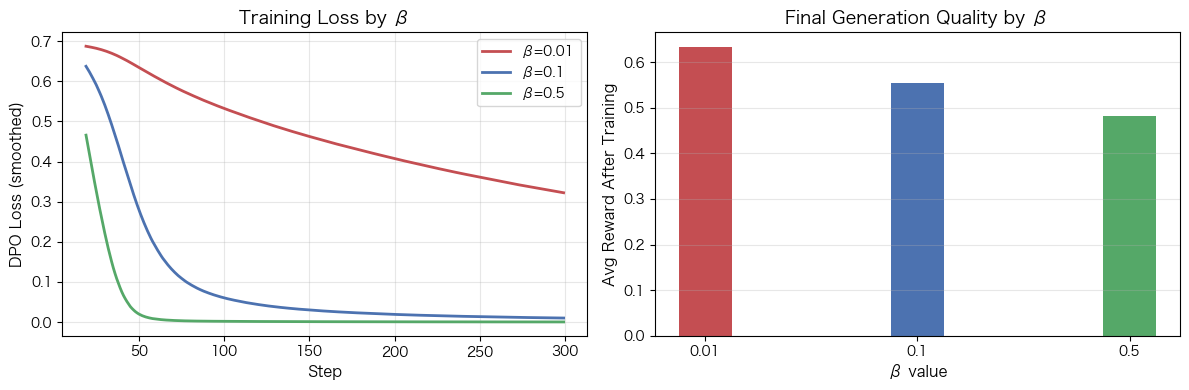

In [14]:
# Sweep over different beta values
betas = [0.01, 0.1, 0.5]
colors = ['#C44E52', '#4C72B0', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for beta_val, color in zip(betas, colors):
    torch.manual_seed(42)
    pol = TinyLM()
    ref = deepcopy(pol)
    for p in ref.parameters():
        p.requires_grad = False
    opt = torch.optim.Adam(pol.parameters(), lr=5e-3)
    losses_b = []
    for step in range(300):
        idx = torch.randint(n_pairs, (64,))
        lp_w = pol.log_probs_of(preferred_t[idx]) - ref.log_probs_of(preferred_t[idx])
        lp_l = pol.log_probs_of(rejected_t[idx]) - ref.log_probs_of(rejected_t[idx])
        loss = -F.logsigmoid(beta_val * (lp_w - lp_l)).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses_b.append(loss.item())

    window = 20
    sm = np.convolve(losses_b, np.ones(window)/window, mode='valid')
    axes[0].plot(range(window-1, len(losses_b)), sm, color=color, lw=2,
                 label=f'\u03b2={beta_val}')

    # Evaluate generation quality
    with torch.no_grad():
        gen = pol.generate(500)
        r = reward_fn(gen)
    axes[1].bar(betas.index(beta_val), r.mean().item(), color=color, width=0.25,
                label=f'\u03b2={beta_val}')

axes[0].set_xlabel("Step", fontsize=11)
axes[0].set_ylabel("DPO Loss (smoothed)", fontsize=11)
axes[0].set_title("Training Loss by \u03b2", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("\u03b2 value", fontsize=11)
axes[1].set_ylabel("Avg Reward After Training", fontsize=11)
axes[1].set_title("Final Generation Quality by \u03b2", fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(betas)))
axes[1].set_xticklabels([str(b) for b in betas])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

info_box("\u03b2 controls the trade-off between learning speed and stability. "
         "Too small and the model overfits to the preference data; "
         "too large and it barely moves from the reference. "
         "In practice, \u03b2 \u2208 [0.1, 0.5] works well for most tasks.",
         title="Choosing \u03b2")

## 总结

### 关键要点

1. **DPO 消除了奖励模型** — 通过从最优策略的闭式解经 Bradley-Terry 到 DPO 损失的数学捷径，直接优化偏好。
2. 损失函数**只需 3 行 PyTorch**：计算偏好和被拒绝输出的对数比，然后将差值通过 log-sigmoid。
3. **2 个模型代替 4 个** — GPU 内存需求是 PPO 的一半。
4. **离线训练**：简单且稳定，但无法探索新策略。
5. **$\beta$** 控制策略可以偏离参考多远（类似于 PPO 中的 KL 系数）。
6. DPO 催生了一**系列变体**：IPO（平方损失）、KTO（无需偏好对）、cDPO（噪声鲁棒）。

### 到目前为止的演进

| Notebook | 算法 | 核心思想 |
|---|---|---|
| 00 | REINFORCE | 策略梯度 — 增加高奖励输出的概率 |
| 01 | PPO | 裁剪目标 + KL 惩罚实现稳定更新 |
| **02** | **DPO** | **跳过奖励模型 — 直接优化偏好** |
| 03 | GRPO | 连评论模型也跳过 — 组相对优势（下一篇！）|

In [15]:
info_box("DPO removed the reward model. But can we go even simpler? "
         "<b>GRPO</b> (used by DeepSeek-R1) removes the value function too \u2014 "
         "and works online. Next notebook!",
         title="What\u2019s Next")